# RuO2 k-slice: Diagonal Cut of the Tetragonal Brillouin Zone

This notebook analyzes a 2D slice through the Brillouin zone defined by:

- **kslice_corner:** `(-0.5, -0.5, -0.5)` (Gamma point)
- **kslice_b1:** `(0.5, 0.5, -0.5)` (direction to M point)
- **kslice_b2:** `(-0.5, -0.5, 0.5)` (direction to A point via Z)
- **kslice_2dkmesh:** `200 x 200` (2D k-mesh for the slice)

This corresponds to a diagonal cut in the tetragonal Brillouin zone.

# Read and Plot RuO2 k-slice Curvature Components
This notebook reads coordinate and curvature data, then plots each curvature component as a heatmap.

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Read coordinates
coords = np.loadtxt('RuO2_up-kslice-coord.dat')
kx, ky = coords[:,0], coords[:,1]

In [4]:
# Read curvature data (all components)
curvup = np.loadtxt('RuO2_up-kslice-curv.dat')
curvdown = np.loadtxt('RuO2_dn-kslice-curv.dat')
curv = curvup + curvdown
n_components = curv.shape[1] if curv.ndim > 1 else 1
print(f'Number of components: {n_components}')
print(f'maximum curvature up: {np.max(curvup)}')
print(f'maximum curvature down: {np.max(curvdown)}')
print(f'maximum curvature total: {np.max(curv)}')

Number of components: 3
maximum curvature up: 3.1159056
maximum curvature down: 61.423411
maximum curvature total: 61.4320491657


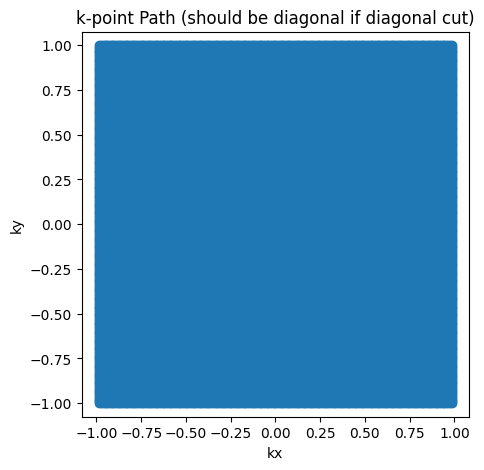

In [5]:
# Visualize the k-point path to check if it's a diagonal cut
plt.figure(figsize=(5,5))
plt.plot(kx, ky, marker='o')
plt.xlabel('kx')
plt.ylabel('ky')
plt.title('k-point Path (should be diagonal if diagonal cut)')
plt.axis('equal')
plt.show()

In [6]:
# Print min/max for kx and ky to inspect the path numerically
print(f'kx: min={kx.min()}, max={kx.max()}')
print(f'ky: min={ky.min()}, max={ky.max()}')
print(f'First 5 k-points:')
for i in range(5):
    print(f'({kx[i]}, {ky[i]})')

kx: min=-0.98425347, max=0.98425347
ky: min=-0.9998274, max=0.9998274
First 5 k-points:
(-0.98425347, -0.9998274)
(-0.97441093, -0.9998274)
(-0.9645684, -0.9998274)
(-0.95472586, -0.9998274)
(-0.94488333, -0.9998274)


Grid shape: (201, 201)


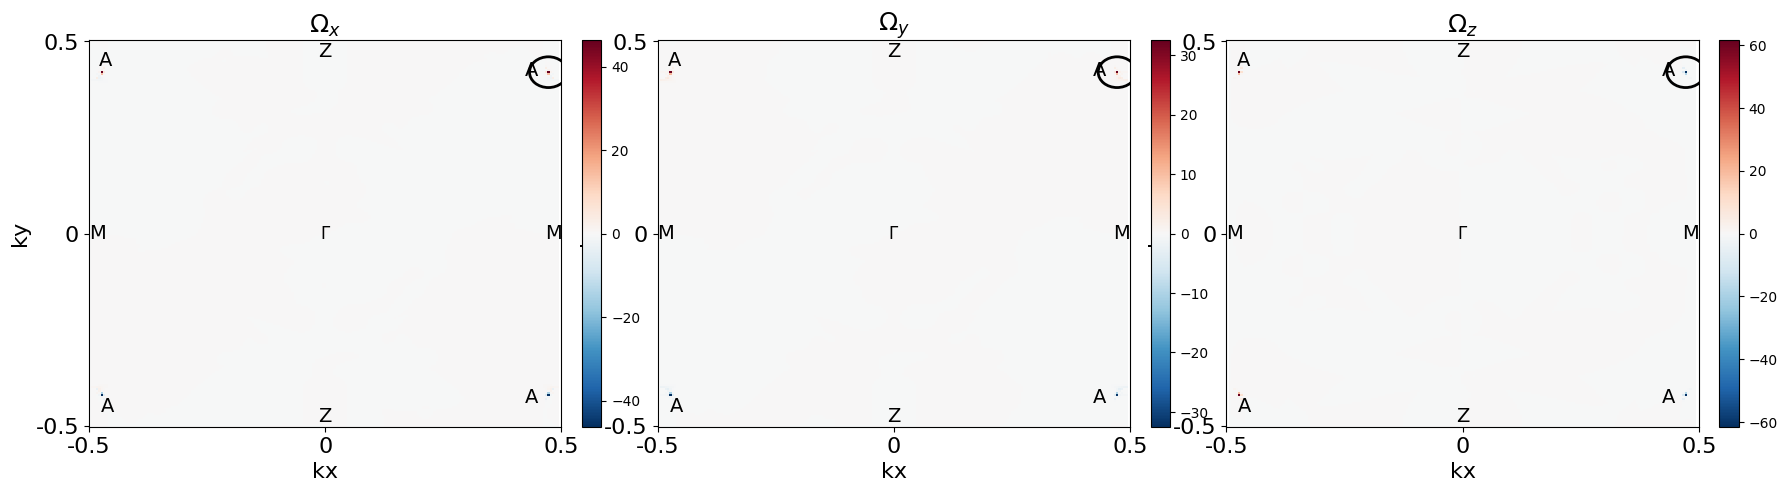

In [10]:
# Plot all three Berry curvature components in one big figure, marking the same point in each subplot
from math import sqrt
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Try to infer grid shape (assume square or rectangular grid)
n_points = len(kx)
grid_shape = None
for n in range(1, int(sqrt(n_points))+2):
    if n_points % n == 0:
        m = n_points // n
        if np.unique(kx).size == n or np.unique(ky).size == m:
            grid_shape = (n, m)
            break
if grid_shape is None:
    grid_shape = (np.unique(kx).size, np.unique(ky).size)

print(f'Grid shape: {grid_shape}')

kx_grid = kx.reshape(grid_shape)
ky_grid = ky.reshape(grid_shape)
label = ['x', 'y', 'z']

# Find the highest value point in the first component
data0 = curv[:,0] if curv.ndim > 1 else curv
data0_grid = data0.reshape(grid_shape)
max_idx = data0_grid.argmax()
max_pos = np.unravel_index(max_idx, data0_grid.shape)
max_kx = kx_grid[max_pos]
max_ky = ky_grid[max_pos]

fig, axes = plt.subplots(1, n_components, figsize=(6*n_components, 5))
if n_components == 1:
    axes = [axes]
for i in range(n_components):
    ax = axes[i]
    data = curv[:,i] if n_components > 1 else curv
    data_grid = data.reshape(grid_shape)
    pcm = ax.pcolormesh(kx_grid, ky_grid, data_grid, shading='auto', cmap='RdBu_r')
    cbar = fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xlabel('kx', fontsize=16)
    ax.set_ylabel('ky', fontsize=16)
    ax.set_xticks([-1, 0, 1])
    ax.set_xticklabels(["-0.5", "0", "0.5"], fontsize=16)
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(["-0.5", "0", "0.5"], fontsize=16)
    ax.text(0.,0., r'$\Gamma$', fontsize=12, ha='center', va='center', color='black')
    ax.text(1,0., r'M', fontsize=14, ha='right', va='center', color='black')
    ax.text(0.,0.9, r'Z', fontsize=14, ha='center', va='bottom', color='black')
    ax.text(-1.,0., 'M', fontsize=14, ha='left', va='center', color='black')
    ax.text(0.,-0.9, r'Z', fontsize=14, ha='center', va='top', color='black')
    ax.text(0.9,0.9, r'A', fontsize=14, ha='right', va='top', color='black')
    ax.text(0.9,-0.9, r'A', fontsize=14, ha='right', va='bottom', color='black')
    ax.text(-0.9,0.95, r'A', fontsize=14, ha='right', va='top', color='black')
    ax.text(-0.95,-0.95, r'A', fontsize=14, ha='left', va='bottom', color='black')
    ax.set_title(fr'$\Omega_{{{label[i]}}}$', fontsize=18)
    # Draw a circle around the same point in all subplots
    circle = Circle((max_kx, max_ky), 0.08, edgecolor='black', facecolor='none', lw=2)
    ax.add_patch(circle)
fig.tight_layout(pad=1.0)
plt.subplots_adjust(wspace=0.1)
plt.savefig('curv.all_components.GMZ.pdf', dpi=1000)
plt.show()